# 04 — Scenario forecasting & economic-events analysis
A single point forecast hides risk. This notebook adds two things a decision-maker actually
wants: (1) **scenario forecasts** — how FY2026-27 growth behaves under an optimistic, a
baseline, and a pessimistic set of conditions; and (2) an **economic-events analysis** that
explains how COVID, the 2022 inflation spike and rate-hike cycle, and the 2026 base revision
shaped India's GDP path.

The scenarios use the *explanatory* Ridge model (GDP growth as a function of its drivers): we
shift the drivers to define each world and read off the implied growth. This is deliberately a
different tool from the univariate SARIMA point forecast in notebook 02 — SARIMA gives the
central number and its statistical interval; the scenarios show assumption-driven spread.

## 0 · Setup & model

In [1]:
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
from pathlib import Path
import warnings; warnings.filterwarnings("ignore")
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({"figure.dpi":110,"savefig.dpi":150,"savefig.bbox":"tight","axes.titleweight":"bold"})
GREEN, GREY, RED, BLUE = "#2a9d8f", "#9aa0a6", "#d1495b", "#2c7fb8"

# >>> YOUR PROJECT FOLDER — change this one line only if you move the project <<<
PROJECT = Path("C:/Users/asus/Projects/GDP")
FIGS = PROJECT/"outputs"/"figures"; FIGS.mkdir(parents=True, exist_ok=True)
FCST = PROJECT/"outputs"/"forecasts"; FCST.mkdir(parents=True, exist_ok=True)
df = pd.read_csv(PROJECT/"data"/"processed"/"composite_master_quarterly.csv")
order_key = lambda q: int(q[:4])*4+int(q[-1])
df = df.sort_values("FY_Quarter", key=lambda s: s.map(order_key)).reset_index(drop=True)

TARGET="GDP_growth"
FEATURES=["FiscalDeficit_pct_GDP","Repo_QtrAvg","CPI_Inflation","IIP_growth","INR_USD",
          "INR_USD_vol","Brent_USD","GFCF_YoY","Exports_YoY","Imports_YoY","M3_level_YoY",
          "CrudeINR_YoY","InvestmentRate","TradeOpenness","GDP_growth_lag1","GDP_growth_lag4"]

work = df[[TARGET]+FEATURES].dropna()
Xtr, ytr = work[FEATURES], work[TARGET]
ridge = make_pipeline(StandardScaler(), Ridge(alpha=5.0)).fit(Xtr, ytr)
print(f"Ridge explanatory model trained on {len(work)} quarters.")


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.1.3 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "C:\Users\asus\AppData\Roaming\Python\Python312\site-packages\ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "C:\Users\asus\AppData\Roaming\Python\Python312\site-packages\traitlets\config\application.py", line 1075, in launch_instance
    app.start()
  File "C:\Users\asus\AppData\Roaming\Python\Python312\site-packages\ipykernel\kernelapp.py", line 739, in start
    self.io_loop.

AttributeError: _ARRAY_API not found


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.1.3 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "C:\Users\asus\AppData\Roaming\Python\Python312\site-packages\ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "C:\Users\asus\AppData\Roaming\Python\Python312\site-packages\traitlets\config\application.py", line 1075, in launch_instance
    app.start()
  File "C:\Users\asus\AppData\Roaming\Python\Python312\site-packages\ipykernel\kernelapp.py", line 739, in start
    self.io_loop.

ImportError: 
A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.1.3 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.



Ridge explanatory model trained on 50 quarters.


## 1 · Defining the scenarios (blended)
Each scenario moves **every relevant driver together** by one historical standard deviation in
its growth-supportive (optimistic) or growth-damaging (pessimistic) direction. Using one
standard deviation makes the size of each shock data-driven rather than arbitrary. The sign
table below encodes which direction is 'good' for growth.

In [2]:
# +1 : higher value supports growth   |   -1 : higher value hurts growth   |   0 : leave unshocked
SIGN = {"IIP_growth":+1,"GFCF_YoY":+1,"Exports_YoY":+1,"M3_level_YoY":+1,"InvestmentRate":+1,
        "CrudeINR_YoY":-1,"Brent_USD":-1,"INR_USD":-1,"INR_USD_vol":-1,
        "CPI_Inflation":-1,"Repo_QtrAvg":-1,
        "FiscalDeficit_pct_GDP":0,"Imports_YoY":0,"TradeOpenness":0,
        "GDP_growth_lag1":0,"GDP_growth_lag4":0}
SHOCK = 0.75                                 # in standard deviations (coordinated move)
sd = Xtr.std()
base_vec = df[FEATURES].ffill().iloc[-1].copy()    # 'current conditions carried forward'

def scenario_vector(direction):
    v = base_vec.copy()
    for f in FEATURES:
        v[f] = base_vec[f] + direction * SIGN[f] * SHOCK * sd[f]
    return v

# show the assumed driver moves for the optimistic case
shifts = pd.DataFrame({
    "baseline": base_vec,
    "optimistic": scenario_vector(+1),
    "pessimistic": scenario_vector(-1)}).round(2)
print(shifts.loc[[f for f in FEATURES if SIGN[f]!=0]].to_string())

                baseline  optimistic  pessimistic
Repo_QtrAvg         5.25        4.36         6.14
CPI_Inflation       3.12        1.71         4.53
IIP_growth          4.77        9.87        -0.33
INR_USD            94.57       88.28       100.87
INR_USD_vol         1.45        1.05         1.84
Brent_USD         112.22       96.06       128.37
GFCF_YoY            0.00        8.98        -8.98
Exports_YoY         0.00        8.22        -8.22
M3_level_YoY        9.92       11.32         8.53
CrudeINR_YoY       76.23       48.10       104.36
InvestmentRate     37.03       38.37        35.69


## 2 · Scenario forecasts for FY2026-27
For each scenario we forecast two quarters, feeding Q1's predicted growth back in as the lag for
Q2 (an iterated two-step forecast). The lag-4 term uses the actual growth from a year earlier.

In [3]:
g = df.set_index("FY_Quarter")[TARGET]
last_actual = g.loc["2025-26 Q4"]
lag4_q1 = g.loc["2025-26 Q1"]; lag4_q2 = g.loc["2025-26 Q2"]

def two_step(direction):
    v = scenario_vector(direction)
    v["GDP_growth_lag1"], v["GDP_growth_lag4"] = last_actual, lag4_q1
    q1 = float(ridge.predict(v.to_frame().T)[0])
    v2 = v.copy(); v2["GDP_growth_lag1"], v2["GDP_growth_lag4"] = q1, lag4_q2
    q2 = float(ridge.predict(v2.to_frame().T)[0])
    return q1, q2

scen = {"Optimistic": two_step(+1), "Baseline": two_step(0), "Pessimistic": two_step(-1)}
table = pd.DataFrame(scen, index=["FY2026-27 Q1","FY2026-27 Q2"]).T.round(2)
table.to_csv(FCST/"gdp_scenarios_FY2026_27.csv")
print(table.to_string())

             FY2026-27 Q1  FY2026-27 Q2
Optimistic           7.94          7.96
Baseline             5.08          4.80
Pessimistic          2.22          1.64


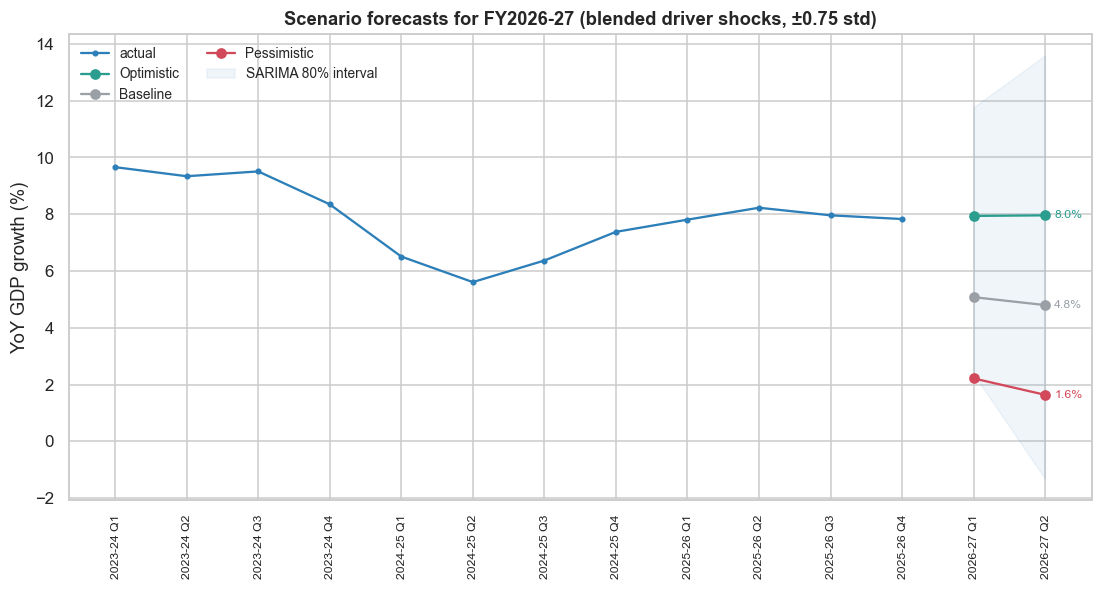

Scenario spread in Q2: 1.6%  to  8.0%


In [4]:
# Scenario fan chart: recent history + the three scenario paths, with the SARIMA 80% band.
show = 12
hist = g.dropna().iloc[-show:]
xh = np.arange(len(hist)); xf = np.arange(len(hist), len(hist)+2)
fig, ax = plt.subplots(figsize=(12,5.5))
ax.plot(xh, hist.values, "-o", color=BLUE, ms=3, label="actual")
colors = {"Optimistic":GREEN, "Baseline":GREY, "Pessimistic":RED}
for name,(q1,q2) in scen.items():
    ax.plot(xf, [q1,q2], "-o", ms=6, color=colors[name], label=name)
    ax.annotate(f"{q2:.1f}%", (xf[-1], q2), color=colors[name], fontsize=8,
                xytext=(6,0), textcoords="offset points", va="center")
# SARIMA statistical interval (from notebook 02) for reference
ax.fill_between(xf, [2.37,-1.32], [11.77,13.60], color=BLUE, alpha=0.07,
                label="SARIMA 80% interval")
labs = list(hist.index)+["2026-27 Q1","2026-27 Q2"]
ax.set_xticks(list(xh)+list(xf)); ax.set_xticklabels(labs, rotation=90, fontsize=8)
ax.set_ylabel("YoY GDP growth (%)"); ax.legend(frameon=False, ncol=2, fontsize=9)
ax.set_title("Scenario forecasts for FY2026-27 (blended driver shocks, ±0.75 std)")
fig.savefig(FIGS/"04a_scenarios.png"); plt.show()
print(f"Scenario spread in Q2: {scen['Pessimistic'][1]:.1f}%  to  {scen['Optimistic'][1]:.1f}%")

## 3 · Economic-events analysis
How major shocks moved GDP. The series itself tells the story: the COVID collapse and rebound,
the post-pandemic normalisation, and the inflation/rate cycle of 2022-23. The base-year revision
of February 2026 is marked where the series switches source.

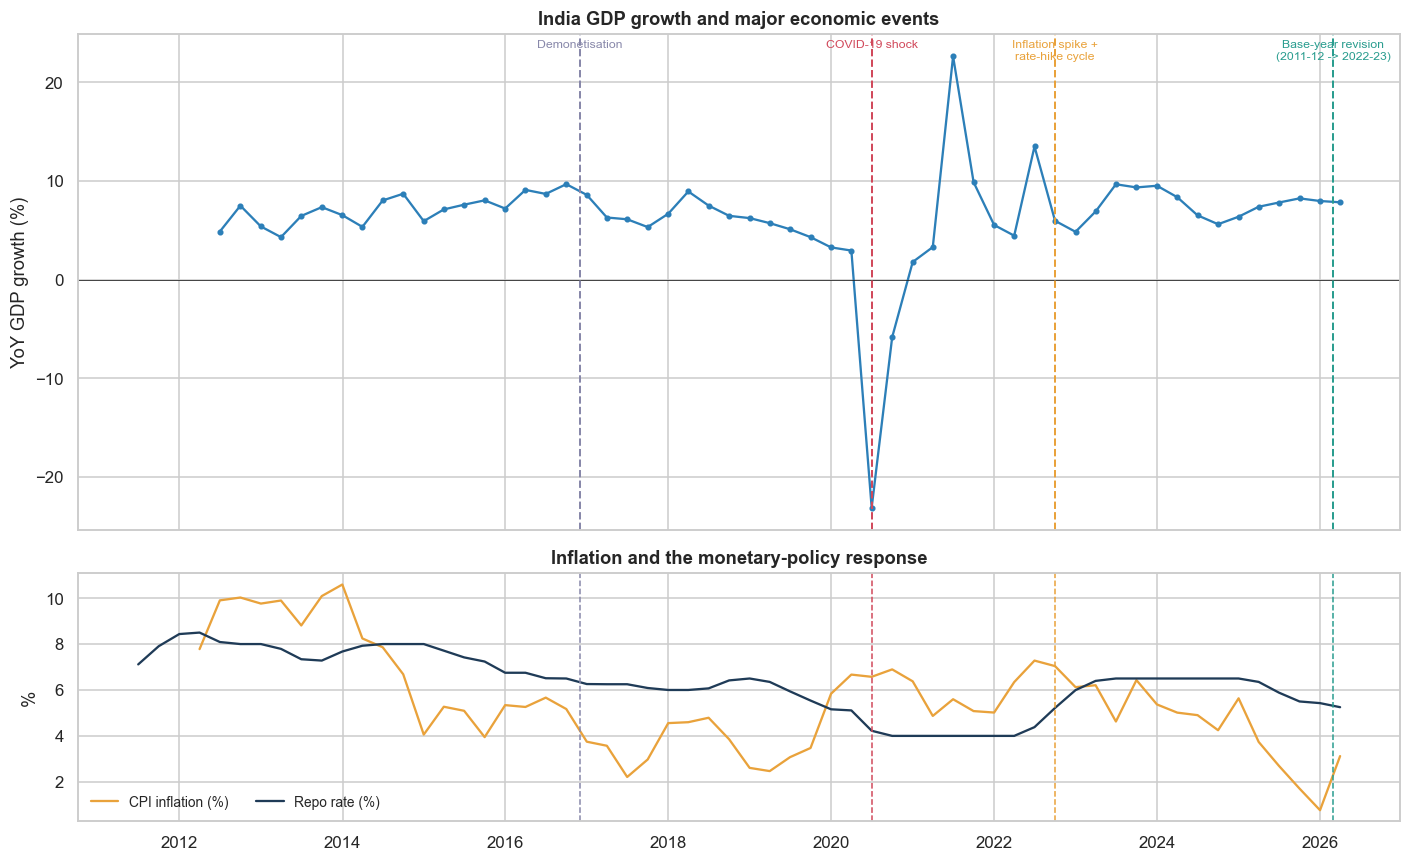

In [5]:
def fq_to_date(q):
    fy, qq = int(q[:4]), int(q[-1]); m={1:6,2:9,3:12,4:3}[qq]; y=fy if qq<=3 else fy+1
    return pd.Timestamp(year=y, month=m, day=1)+pd.offsets.MonthEnd(0)
dts = df["FY_Quarter"].map(fq_to_date)

events = [
    ("2016-11-30","Demonetisation","#8888aa"),
    ("2020-06-30","COVID-19 shock","#d1495b"),
    ("2022-09-30","Inflation spike +\nrate-hike cycle","#e9a23b"),
    ("2026-02-28","Base-year revision\n(2011-12 -> 2022-23)","#2a9d8f"),
]
fig, (a1,a2) = plt.subplots(2,1, figsize=(13,8), sharex=True, gridspec_kw={"height_ratios":[2,1]})
a1.plot(dts, df[TARGET], "-o", color=BLUE, ms=3)
a1.axhline(0, color="k", lw=0.5)
for d,lab,c in events:
    x=pd.Timestamp(d); a1.axvline(x, color=c, ls="--", lw=1.3)
    a1.annotate(lab, (x, a1.get_ylim()[1]), color=c, fontsize=8, ha="center", va="top",
                xytext=(0,-4), textcoords="offset points")
a1.set_ylabel("YoY GDP growth (%)"); a1.set_title("India GDP growth and major economic events")

a2.plot(dts, df["CPI_Inflation"], color="#e9a23b", label="CPI inflation (%)")
a2.plot(dts, df["Repo_QtrAvg"], color="#1f3b57", label="Repo rate (%)")
for d,_,c in events:
    a2.axvline(pd.Timestamp(d), color=c, ls="--", lw=1.0)
a2.set_ylabel("%"); a2.legend(frameon=False, fontsize=9, ncol=2)
a2.set_title("Inflation and the monetary-policy response")
fig.tight_layout(); fig.savefig(FIGS/"04b_events.png"); plt.show()

**Reading the events.**
- **COVID-19 (FY2020-21):** the sharpest contraction in the series (about -23% YoY in Q1) followed
  by an equally sharp base-effect rebound. It dominates the variance of the whole sample and is why
  the forecasting model carries a COVID dummy.
- **Inflation spike & rate hikes (2022-23):** CPI inflation pushed above the RBI's comfort zone and
  the repo rate was raised from 4.0% to 6.5%; growth moderated from the rebound highs as policy
  tightened, visible in the lower panel.
- **Demonetisation (Nov 2016):** a smaller, temporary dip in momentum.
- **Base-year revision (Feb 2026):** not an economic shock but a measurement change; reported growth
  for recent quarters shifted (see notebook 01), which is why our target splices the two series.

## 4 · Key takeaways
- **Scenario range matters more than a single number.** Under a coordinated 0.75-standard-deviation
  move in the drivers, FY2026-27 Q2 growth ranges roughly from the pessimistic to the optimistic
  figure above — a band a planner can act on, versus a lone point estimate.
- **The drivers that move the scenarios are the ones the model flagged:** industrial production and
  investment on the real side, oil/rupee and inflation/rates on the macro side.
- **Model comparison (notebook 02):** the random walk is the accuracy benchmark; regularized linear
  models match it and add interpretability; tree ensembles overfit the ~50-quarter sample.
- **Uncertainty is explicit:** the SARIMA 80% interval (statistical uncertainty) and the scenario
  spread (assumption uncertainty) are shown together, so the forecast is never presented as a single
  certain value.
- **Events leave clear fingerprints:** COVID and the 2022 inflation/rate cycle are the two dominant
  features of the recent GDP path, and the 2026 rebasing is a measurement break, not a growth event.